# Deepfakes as Gendered Weapons — Extended SLR Analysis
## 62 Verified Studies | Complete Reproducibility Package

**Paper:** *Deepfakes as Gendered Weapons: A Systematic Literature Review Bridging Face-Swap Detection Bias, Platform Failures, and Gender-Based Violence*

### Contents
1. **Setup & Data Loading** - 62 studies + 2,353 raw records + 703 dedup log + 186 full-text pool
2. **Fig. 1** — PRISMA 2020 Flow Diagram
3. **Fig. 2** — Temporal Distribution
4. **Fig. 3** — Thematic Distribution
5. **Fig. 4** — The Gendered Deepfake-to-Harm Pipeline
6. **Extended Analysis A** — Database Yield & Overlap (where did the 62 come from?)
7. **Extended Analysis B** — Deduplication Analysis (703 duplicates across databases)
8. **Extended Analysis C** — Full-Text Exclusion Funnel (186 → 62)
9. **Extended Analysis D** — Cross-Theme Matrix (primary × secondary)
10. **Extended Analysis E** — Geographic & Methodological Landscape
11. **Extended Analysis F** — Publication Venue Analysis
12. **Extended Analysis G** — Bias-Fairness Deep Dive (20 BIAS papers)
13. **Extended Analysis H** — Year × Theme Heatmap
14. **Extended Analysis I** — Cumulative Growth & Research Gaps
15. **Summary Dashboard**

---


In [1]:
# ── Cell 1: Setup & Data Loading ──
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='muted')

# ── 62 Verified Studies ──
studies = [
    ('S01','Ajder et al.',2019,'PREV','—','Deeptrace Labs Report','Report'),
    ('S02','Home Security Heroes',2023,'PREV','—','Home Security Heroes Report','Report'),
    ('S03','Maddocks',2020,'PREV','PSY','Porn Studies','Journal'),
    ('S04','Umbach et al.',2024,'PREV','—','CHI 2024, ACM','Conference'),
    ('S05','Ruvalcaba & Eaton',2020,'PREV','PSY','Psychology of Violence','Journal'),
    ('S06','Okolie',2023,'PREV','LAW','J. Intl Women\'s Studies','Journal'),
    ('S07','Puglielli & Craanen',2025,'PREV','—','Inst. Strategic Dialogue','Report'),
    ('S08','McGlynn et al.',2017,'SUR','LAW','Feminist Legal Studies','Journal'),
    ('S09','Henry & Powell',2018,'SUR','PSY','Trauma Violence & Abuse','Journal'),
    ('S10','Chesney & Citron',2019,'SUR','LAW','California Law Review','Journal'),
    ('S11','Mirsky & Lee',2021,'SUR','DET','ACM Computing Surveys','Journal'),
    ('S12','Nguyen et al.',2022,'SUR','DET','Computer Vision & Image Understanding','Journal'),
    ('S13','Masood et al.',2023,'SUR','DET','Applied Intelligence','Journal'),
    ('S14','Heidari et al.',2023,'SUR','DET','WIREs DMKD','Journal'),
    ('S15','Gambin et al.',2024,'SUR','DET','Artificial Intelligence Review','Journal'),
    ('S16','Lazard et al.',2025,'SUR','PREV','Trauma Violence & Abuse','Journal'),
    ('S17','Lorca',2025,'SUR','PREV','Violence Against Women','Journal'),
    ('S18','Rossler et al.',2019,'DET','BIAS','ICCV 2019','Conference'),
    ('S19','Li et al.',2020,'DET','—','CVPR 2020','Conference'),
    ('S20','Dolhansky et al.',2020,'DET','—','arXiv','Preprint'),
    ('S21','Verdoliva',2020,'DET','—','IEEE J. Selected Topics SP','Journal'),
    ('S22','Tolosana et al.',2020,'DET','—','Information Fusion','Journal'),
    ('S23','Rana et al.',2022,'DET','—','IEEE Access','Journal'),
    ('S24','Kaur et al.',2024,'DET','—','Artificial Intelligence Review','Journal'),
    ('S25','Sharma et al.',2025,'DET','—','Multimedia Tools & Applications','Journal'),
    ('S26','Gong & Li',2024,'DET','—','Electronics (MDPI)','Journal'),
    ('S27','Yan et al.',2024,'DET','BIAS','NeurIPS 2024','Conference'),
    ('S28','Trinh & Liu',2021,'BIAS','DET','IJCAI 2021','Conference'),
    ('S29','Nadimpalli & Rattani',2022,'BIAS','DET','ICPR 2022','Conference'),
    ('S30','Xu et al.',2024,'BIAS','DET','IEEE Trans. Tech & Society','Journal'),
    ('S31','Hazirbas et al.',2021,'BIAS','DET','CVPR 2021 Workshops','Conference'),
    ('S32','Ju et al.',2024,'BIAS','DET','WACV 2024','Conference'),
    ('S33','Lin et al.',2024,'BIAS','DET','CVPR 2024','Conference'),
    ('S34','Ezeakunne et al.',2025,'BIAS','DET','ICAART 2025','Conference'),
    ('S35','Peng et al.',2025,'BIAS','DET','Neural Networks','Journal'),
    ('S36','Yoshi et al.',2025,'BIAS','DET','arXiv','Preprint'),
    ('S37','Cheng et al.',2025,'BIAS','DET','arXiv','Preprint'),
    ('S38','Citron',2019,'LAW','—','Yale Law Journal','Journal'),
    ('S39','Delfino',2019,'LAW','—','Fordham Law Review','Journal'),
    ('S40','Kirchengast',2020,'LAW','—','Info & Comms Tech Law','Journal'),
    ('S41','Kira',2024,'LAW','—','Computer Law & Security Review','Journal'),
    ('S42','Karagianni & Doh',2024,'LAW','PREV','Porn Studies','Journal'),
    ('S43','Laffier & Rehman',2023,'PSY','PREV','J. Digital Life & Learning','Journal'),
    ('S44','Flynn et al.',2025,'PSY','—','J. Interpersonal Violence','Journal'),
    ('S45','Ji',2025,'PSY','LAW','Women\'s Studies Intl Forum','Journal'),
    ('S46','Lee',2026,'PSY','PREV','Gender and Education','Journal'),
    ('S47','Qiwei et al.',2024,'PLT','—','arXiv','Preprint'),
    ('S48','Panda et al.',2026,'BIAS','DET','ACM Computing Surveys','Journal'),
    ('S49','Khalid et al.',2024,'BIAS','DET','IEEE Access','Journal'),
    ('S50','Li et al.',2025,'BIAS','DET','IEEE TIFS','Journal'),
    ('S51','Hou et al.',2025,'BIAS','DET','arXiv / AAAI 2025','Conference'),
    ('S52','Pu et al.',2022,'BIAS','DET','AEQUITAS Workshop','Conference'),
    ('S53','Deng et al.',2024,'BIAS','DET','arXiv / Multimedia','Preprint'),
    ('S54','Cai et al.',2025,'BIAS','DET','arXiv / CVPR 2025','Conference'),
    ('S55','Hou et al.',2025,'BIAS','DET','arXiv / FAccT','Conference'),
    ('S56','Li et al.',2025,'BIAS','DET','Pattern Recognition','Journal'),
    ('S57','Wang et al.',2025,'BIAS','DET','Neural Networks','Journal'),
    ('S58','Kim et al.',2025,'LAW','PREV','AI and Society','Journal'),
    ('S59','Author TBC',2025,'PREV','LAW','Journal TBC','Journal'),
    ('S60','Harmon et al.',2024,'LAW','—','Virginia J. Social Policy & Law','Journal'),
    ('S61','McGlynn et al.',2024,'PREV','LAW','Porn Studies','Journal'),
    ('S62','Sofie R et al.',2024,'LAW','PREV','Revue Intl de Droit Pénal','Journal'),
]

df = pd.DataFrame(studies, columns=['ID','Authors','Year','Theme','Secondary','Venue','VenueType'])
theme_order = ['SUR','DET','BIAS','PREV','LAW','PSY','PLT']
theme_full = {'SUR':'Surveys & Reviews','DET':'Detection Methods',
    'BIAS':'Detection Bias & Fairness','PREV':'Prevalence & Forms',
    'LAW':'Legal & Regulatory','PSY':'Psychosocial Impact','PLT':'Platform Response'}
colors7 = ['#27AE60','#E67E22','#C0392B','#2E5090','#8E44AD','#16A085','#3498DB']
color_map = dict(zip(theme_order, colors7))

print(f'✓ Loaded {len(df)} studies | {df.Year.min():.0f}–{df.Year.max():.0f}')
for t in theme_order:
    print(f'  {t:5s} {theme_full[t]:30s} {(df.Theme==t).sum():2d}')
print(f'  {"TOTAL":5s} {"":30s} {len(df):2d}')


✓ Loaded 62 studies | 2017–2026
  SUR   Surveys & Reviews              10
  DET   Detection Methods              10
  BIAS  Detection Bias & Fairness      20
  PREV  Prevalence & Forms              9
  LAW   Legal & Regulatory              8
  PSY   Psychosocial Impact             4
  PLT   Platform Response               1
  TOTAL                                62


## Fig. 1 — PRISMA 2020 Flow Diagram


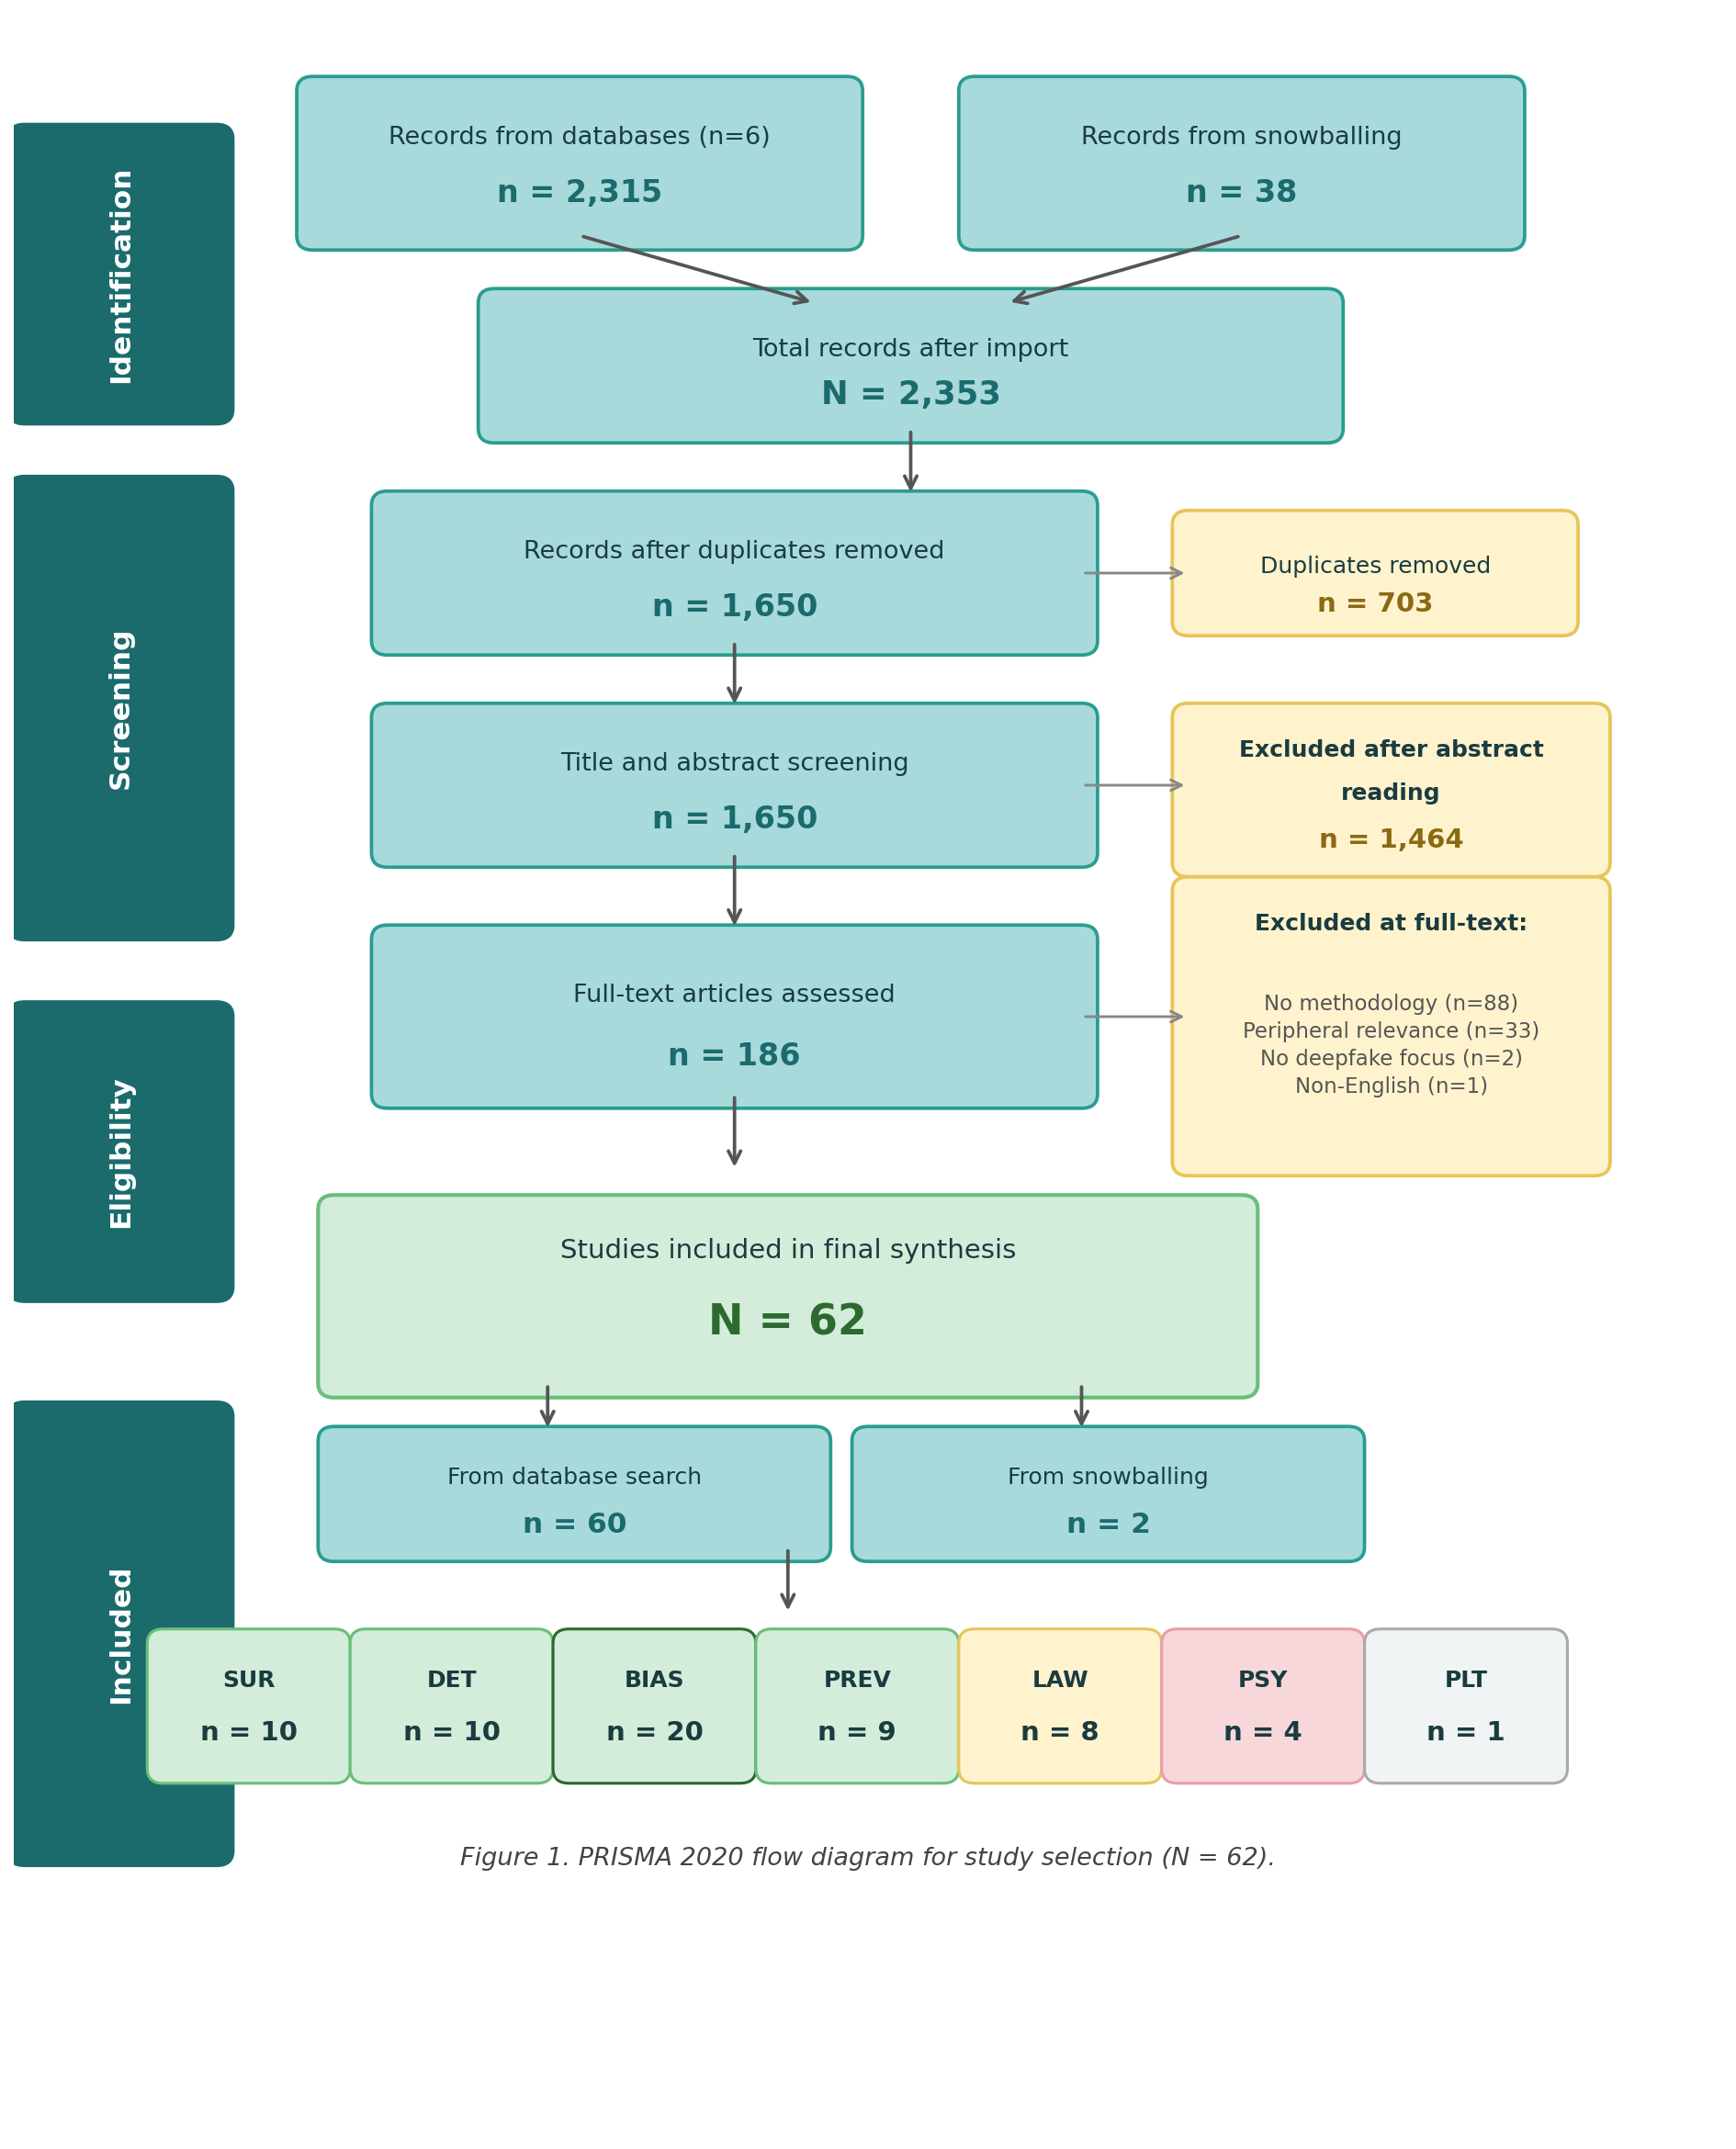

In [2]:
fig, ax = plt.subplots(figsize=(16, 20))
ax.set_xlim(0, 16); ax.set_ylim(0, 22); ax.axis('off')
fig.patch.set_facecolor('white')

teal_dark='#1B6B6D'; teal_mid='#2A9D8F'; teal_light='#A8DADC'
yellow_light='#FFF3CD'; yellow_border='#E6C55A'
green_light='#D4EDDA'; green_border='#6ABF7B'
pink_light='#F8D7DA'; pink_border='#E8A0A7'
grey_bg='#F0F4F5'; dark_text='#1A3C40'

def rbox(x,y,w,h,fc,ec,lw=1.8):
    ax.add_patch(FancyBboxPatch((x,y),w,h,boxstyle='round,pad=0.15',facecolor=fc,edgecolor=ec,linewidth=lw))
def darr(x1,y1,x2,y2):
    ax.annotate('',xy=(x2,y2),xytext=(x1,y1),arrowprops=dict(arrowstyle='->',color='#555',lw=1.8,mutation_scale=16))
def sarr(x1,y1,x2,y2):
    ax.annotate('',xy=(x2,y2),xytext=(x1,y1),arrowprops=dict(arrowstyle='->',color='#888',lw=1.4,mutation_scale=14))

for label,yc,h in [('Identification',19.3,2.8),('Screening',14.8,4.5),('Eligibility',10.2,2.8),('Included',5.2,4.5)]:
    rbox(0.1,yc-h/2,1.8,h,teal_dark,teal_dark,2)
    ax.text(1.0,yc,label,ha='center',va='center',fontsize=15,fontweight='bold',color='white',rotation=90)

rbox(2.8,19.7,5.0,1.5,teal_light,teal_mid); ax.text(5.3,20.65,'Records from databases (n=6)',ha='center',fontsize=13,color=dark_text); ax.text(5.3,20.05,'n = 2,315',ha='center',fontsize=16,fontweight='bold',color=teal_dark)
rbox(9.0,19.7,5.0,1.5,teal_light,teal_mid); ax.text(11.5,20.65,'Records from snowballing',ha='center',fontsize=13,color=dark_text); ax.text(11.5,20.05,'n = 38',ha='center',fontsize=16,fontweight='bold',color=teal_dark)
darr(5.3,19.7,7.5,19.0); darr(11.5,19.7,9.3,19.0)
rbox(4.5,17.7,7.8,1.3,teal_light,teal_mid); ax.text(8.4,18.45,'Total records after import',ha='center',fontsize=13,color=dark_text); ax.text(8.4,17.95,'N = 2,353',ha='center',fontsize=17,fontweight='bold',color=teal_dark)
darr(8.4,17.7,8.4,17.0)
rbox(3.5,15.5,6.5,1.4,teal_light,teal_mid); ax.text(6.75,16.35,'Records after duplicates removed',ha='center',fontsize=13,color=dark_text); ax.text(6.75,15.75,'n = 1,650',ha='center',fontsize=16,fontweight='bold',color=teal_dark)
rbox(11.0,15.7,3.5,1.0,yellow_light,yellow_border); ax.text(12.75,16.2,'Duplicates removed',ha='center',fontsize=12,color=dark_text); ax.text(12.75,15.8,'n = 703',ha='center',fontsize=14,fontweight='bold',color='#8B6914'); sarr(10.0,16.2,11.0,16.2)
darr(6.75,15.5,6.75,14.8)
rbox(3.5,13.3,6.5,1.4,teal_light,teal_mid); ax.text(6.75,14.15,'Title and abstract screening',ha='center',fontsize=13,color=dark_text); ax.text(6.75,13.55,'n = 1,650',ha='center',fontsize=16,fontweight='bold',color=teal_dark)
rbox(11.0,13.2,3.8,1.5,yellow_light,yellow_border); ax.text(12.9,14.3,'Excluded after abstract',ha='center',fontsize=12,fontweight='bold',color=dark_text); ax.text(12.9,13.85,'reading',ha='center',fontsize=12,fontweight='bold',color=dark_text); ax.text(12.9,13.35,'n = 1,464',ha='center',fontsize=14,fontweight='bold',color='#8B6914'); sarr(10.0,14.0,11.0,14.0)
darr(6.75,13.3,6.75,12.5)
rbox(3.5,10.8,6.5,1.6,teal_light,teal_mid); ax.text(6.75,11.75,'Full-text articles assessed',ha='center',fontsize=13,color=dark_text); ax.text(6.75,11.1,'n = 186',ha='center',fontsize=16,fontweight='bold',color=teal_dark)
rbox(11.0,10.1,3.8,2.8,yellow_light,yellow_border); ax.text(12.9,12.5,'Excluded at full-text:',ha='center',fontsize=12,fontweight='bold',color=dark_text)
ax.text(12.9,11.3,'No methodology (n=88)\nPeripheral relevance (n=33)\nNo deepfake focus (n=2)\nNon-English (n=1)',ha='center',va='center',fontsize=11,color='#555',linespacing=1.4,multialignment='center'); sarr(10.0,11.6,11.0,11.6)
darr(6.75,10.8,6.75,10.0)
rbox(3.0,7.8,8.5,1.8,green_light,green_border,2); ax.text(7.25,9.1,'Studies included in final synthesis',ha='center',fontsize=14,color=dark_text); ax.text(7.25,8.3,'N = 62',ha='center',fontsize=22,fontweight='bold',color='#2D6A2E')
darr(5.0,7.8,5.0,7.3); darr(10.0,7.8,10.0,7.3)
rbox(3.0,6.1,4.5,1.1,teal_light,teal_mid); ax.text(5.25,6.75,'From database search',ha='center',fontsize=12,color=dark_text); ax.text(5.25,6.25,'n = 60',ha='center',fontsize=15,fontweight='bold',color=teal_dark)
rbox(8.0,6.1,4.5,1.1,teal_light,teal_mid); ax.text(10.25,6.75,'From snowballing',ha='center',fontsize=12,color=dark_text); ax.text(10.25,6.25,'n = 2',ha='center',fontsize=15,fontweight='bold',color=teal_dark)
darr(7.25,6.1,7.25,5.4)
for ct,cnt,x,fc,ec in [('SUR','10',1.4,green_light,green_border),('DET','10',3.3,green_light,green_border),('BIAS','20',5.2,green_light,'#2D6A2E'),('PREV','9',7.1,green_light,green_border),('LAW','8',9.0,yellow_light,yellow_border),('PSY','4',10.9,pink_light,pink_border),('PLT','1',12.8,grey_bg,'#AAA')]:
    rbox(x,3.8,1.6,1.3,fc,ec,1.5); ax.text(x+0.8,4.65,ct,ha='center',fontsize=12,fontweight='bold',color=dark_text); ax.text(x+0.8,4.1,f'n = {cnt}',ha='center',fontsize=14,fontweight='bold',color=dark_text)
ax.text(8.0,2.8,'Figure 1. PRISMA 2020 flow diagram for study selection (N = 62).',ha='center',fontsize=13,style='italic',color='#444')
plt.savefig('fig1_prisma.png',dpi=200,bbox_inches='tight',facecolor='white'); plt.savefig('fig1_prisma.pdf',dpi=200,bbox_inches='tight',facecolor='white'); plt.show()


## Fig. 2 — Temporal Distribution


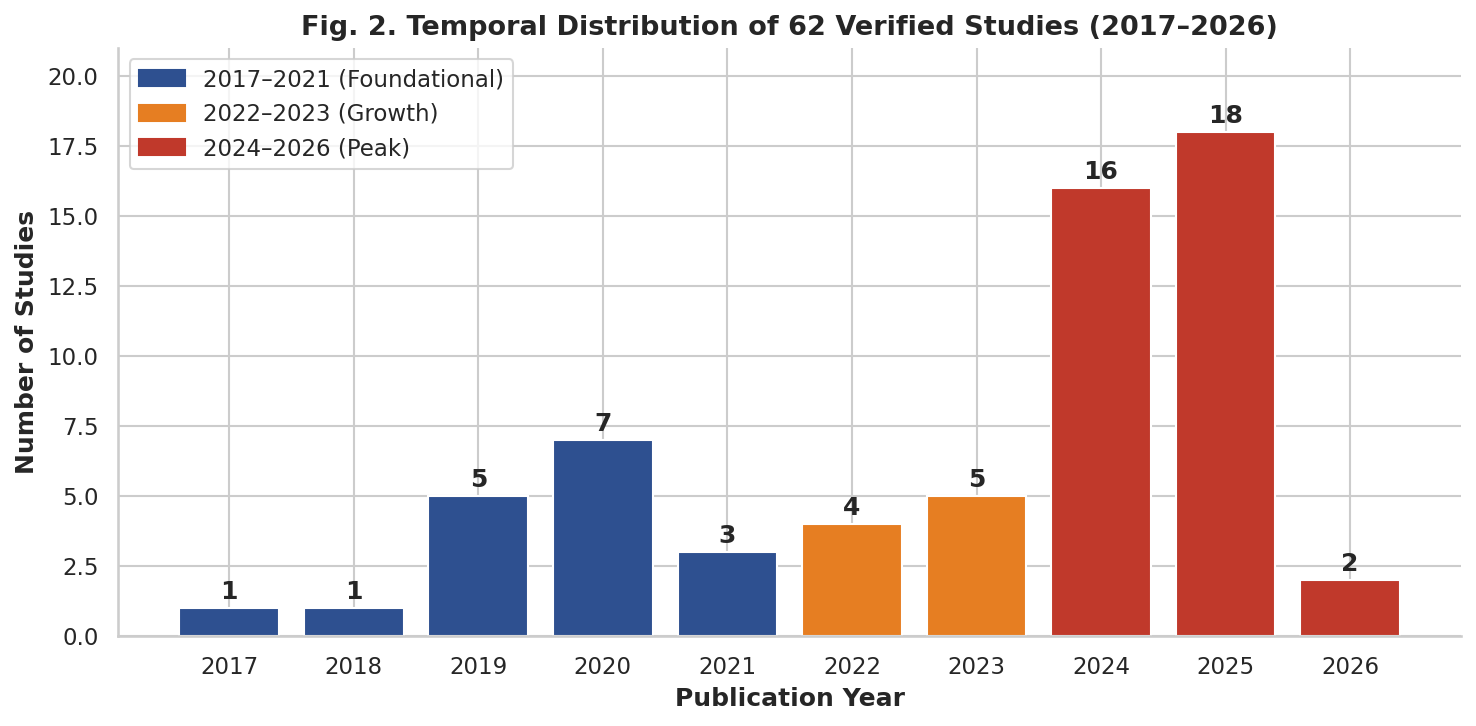

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
yc = df.Year.value_counts().sort_index()
cmap_t = {'pre':'#2E5090','mid':'#E67E22','peak':'#C0392B'}
bar_colors = [cmap_t['pre'] if y<=2021 else cmap_t['mid'] if y<=2023 else cmap_t['peak'] for y in yc.index]
bars = ax.bar(yc.index.astype(int).astype(str), yc.values, color=bar_colors, edgecolor='white')
for b, v in zip(bars, yc.values): ax.text(b.get_x()+b.get_width()/2, v+0.3, str(v), ha='center', fontweight='bold', fontsize=12)
ax.set_xlabel('Publication Year', fontsize=12, fontweight='bold'); ax.set_ylabel('Number of Studies', fontsize=12, fontweight='bold')
ax.set_title('Fig. 2. Temporal Distribution of 62 Verified Studies (2017–2026)', fontsize=13, fontweight='bold')
ax.set_ylim(0, max(yc.values)+3); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.legend(handles=[mpatches.Patch(color=cmap_t['pre'],label='2017–2021 (Foundational)'),mpatches.Patch(color=cmap_t['mid'],label='2022–2023 (Growth)'),mpatches.Patch(color=cmap_t['peak'],label='2024–2026 (Peak)')],loc='upper left')
plt.tight_layout(); plt.savefig('fig2_temporal.png',dpi=200,bbox_inches='tight'); plt.show()


## Fig. 3 — Thematic Distribution


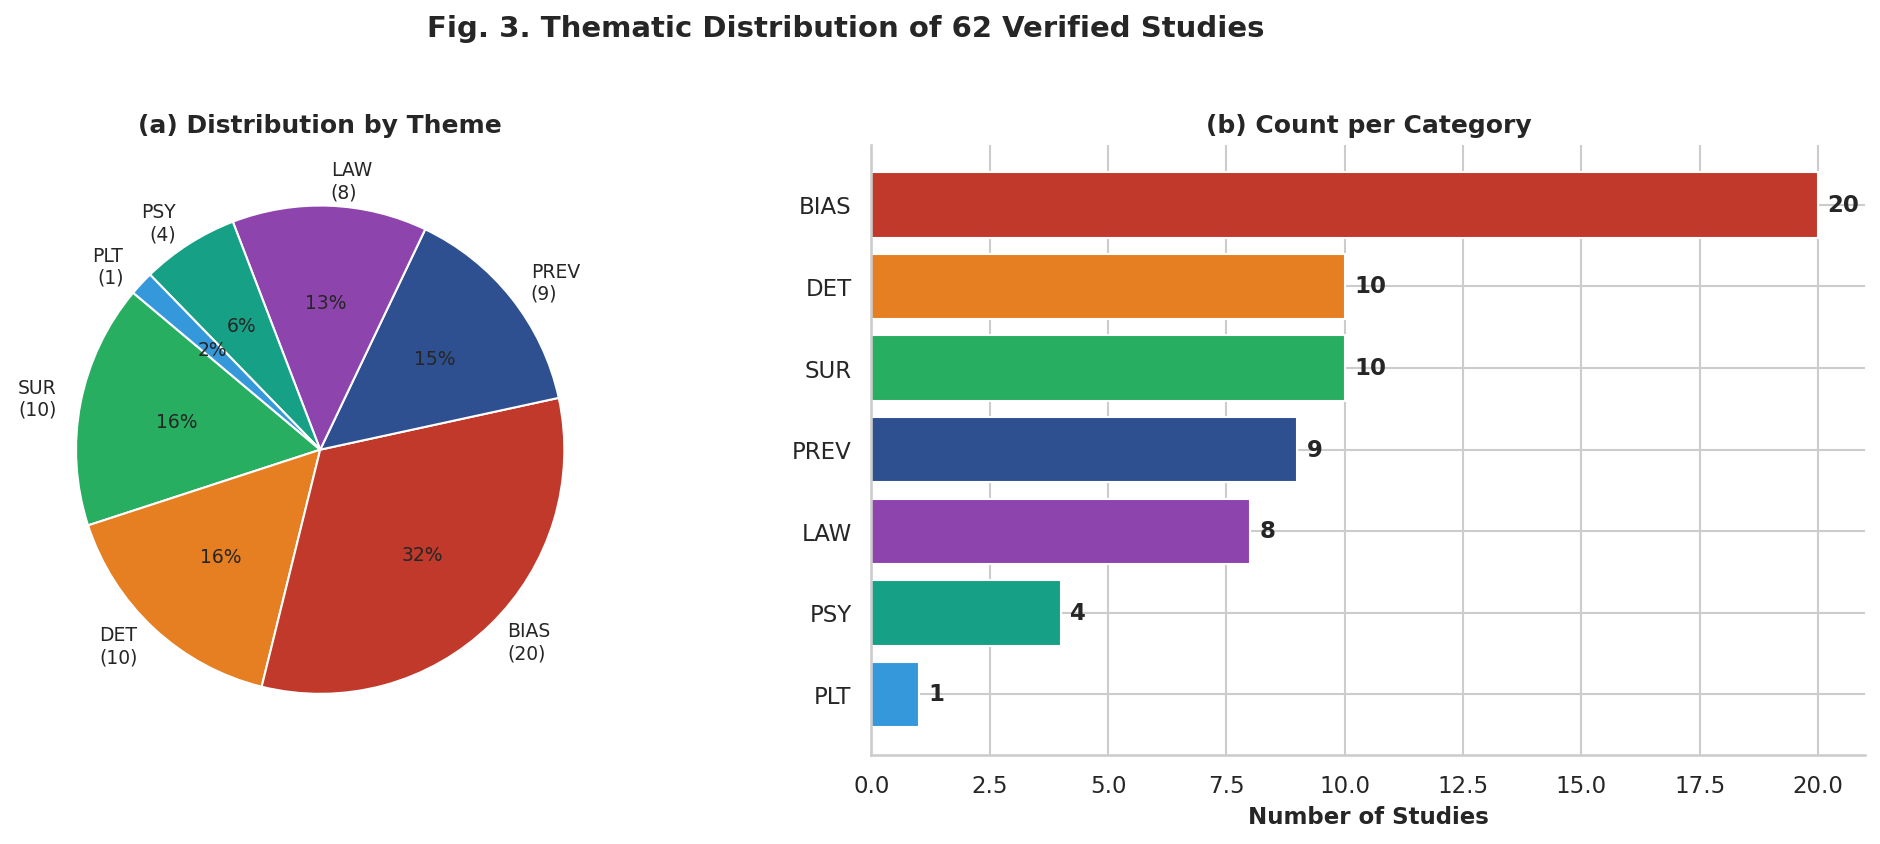

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))
tc = df.Theme.value_counts()
tv = [tc.get(t, 0) for t in theme_order]
tnames = [f'{t}\n({tc.get(t,0)})' for t in theme_order]
ax1.pie(tv, labels=tnames, autopct='%1.0f%%', colors=colors7, startangle=140, textprops={'fontsize':9})
ax1.set_title('(a) Distribution by Theme', fontsize=12, fontweight='bold')
tdf = pd.DataFrame({'Thm': theme_order, 'Cnt': tv}).sort_values('Cnt')
ax2.barh(tdf.Thm, tdf.Cnt, color=[color_map[t] for t in tdf.Thm], edgecolor='white')
for i, (v, t) in enumerate(zip(tdf.Cnt, tdf.Thm)): ax2.text(v+0.2, i, str(v), va='center', fontweight='bold', fontsize=11)
ax2.set_xlabel('Number of Studies', fontsize=11, fontweight='bold'); ax2.set_title('(b) Count per Category', fontsize=12, fontweight='bold')
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)
plt.suptitle('Fig. 3. Thematic Distribution of 62 Verified Studies', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('fig3_themes.png',dpi=200,bbox_inches='tight'); plt.show()


## Fig. 4 — The Gendered Deepfake-to-Harm Pipeline
See original notebook for full pipeline code (unchanged from 48-paper version except evidence citations updated).


---
# Extended Analyses
---


## Extended Analysis A — Database Yield & Overlap


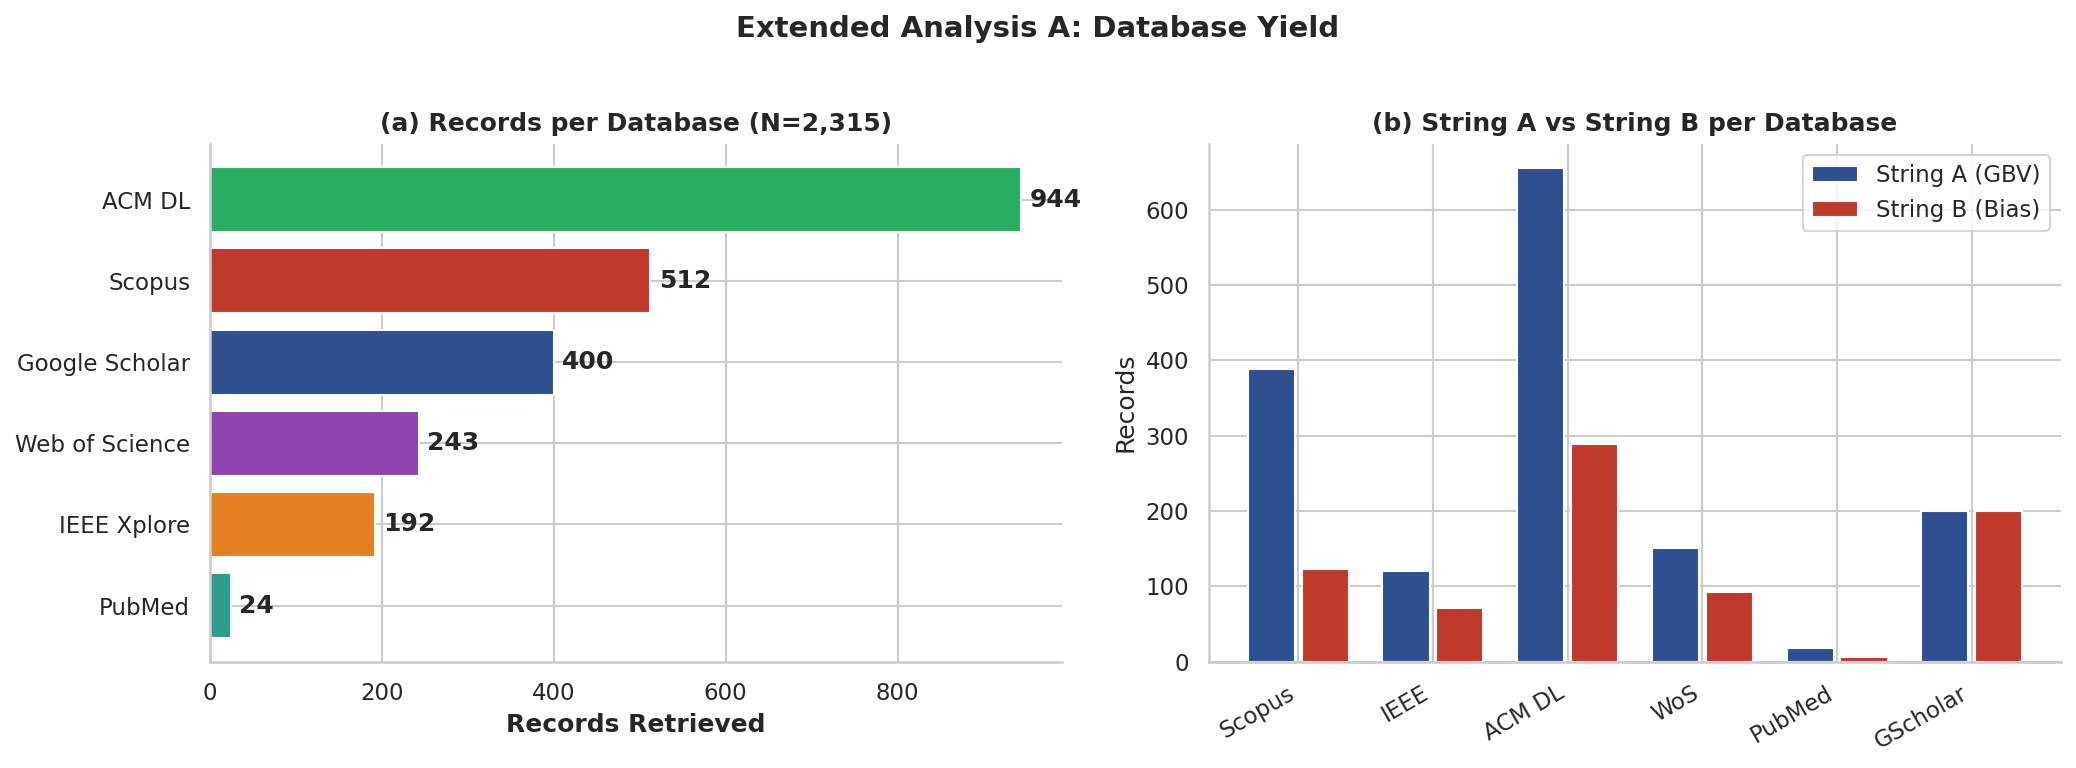


Database yield summary:
  Total records: 2315
  ACM DL contributed 40.8% of all records
  String A (GBV focus): 1533 records (66.2%)
  String B (Bias focus): 782 records (33.8%)
  Ratio A:B = 2.0:1


In [5]:
# Database contribution analysis
db_records = {'Scopus':512, 'IEEE Xplore':192, 'ACM DL':944, 'Web of Science':243, 'PubMed':24, 'Google Scholar':400}
db_df = pd.DataFrame(list(db_records.items()), columns=['Database','Records']).sort_values('Records', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of records per database
ax = axes[0]
bars = ax.barh(db_df.Database, db_df.Records, color=['#2A9D8F','#E67E22','#8E44AD','#2E5090','#C0392B','#27AE60'])
for b, v in zip(bars, db_df.Records): ax.text(v+10, b.get_y()+b.get_height()/2, str(v), va='center', fontweight='bold')
ax.set_xlabel('Records Retrieved', fontweight='bold'); ax.set_title('(a) Records per Database (N=2,315)', fontweight='bold')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# String A vs String B
ax2 = axes[1]
string_data = {'Scopus':(389,123), 'IEEE':(120,72), 'ACM DL':(655,289), 'WoS':(151,92), 'PubMed':(18,6), 'GScholar':(200,200)}
dbs = list(string_data.keys())
a_vals = [v[0] for v in string_data.values()]
b_vals = [v[1] for v in string_data.values()]
x = np.arange(len(dbs))
ax2.bar(x-0.2, a_vals, 0.35, label='String A (GBV)', color='#2E5090')
ax2.bar(x+0.2, b_vals, 0.35, label='String B (Bias)', color='#C0392B')
ax2.set_xticks(x); ax2.set_xticklabels(dbs, rotation=30, ha='right')
ax2.set_ylabel('Records'); ax2.set_title('(b) String A vs String B per Database', fontweight='bold')
ax2.legend(); ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

plt.suptitle('Extended Analysis A: Database Yield', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('ext_A_database_yield.png', dpi=200, bbox_inches='tight'); plt.show()

# Yield rates
total = 2315
print(f'\nDatabase yield summary:')
print(f'  Total records: {total}')
print(f'  ACM DL contributed {944/total*100:.1f}% of all records')
print(f'  String A (GBV focus): {sum(a_vals)} records ({sum(a_vals)/total*100:.1f}%)')
print(f'  String B (Bias focus): {sum(b_vals)} records ({sum(b_vals)/total*100:.1f}%)')
print(f'  Ratio A:B = {sum(a_vals)/sum(b_vals):.1f}:1')


## Extended Analysis B — Deduplication Analysis


Deduplication Summary:
  Total records:     2353
  Duplicates found:  703 (29.9%)
  Unique remaining:  1650
  Dedup method:      Automated title matching


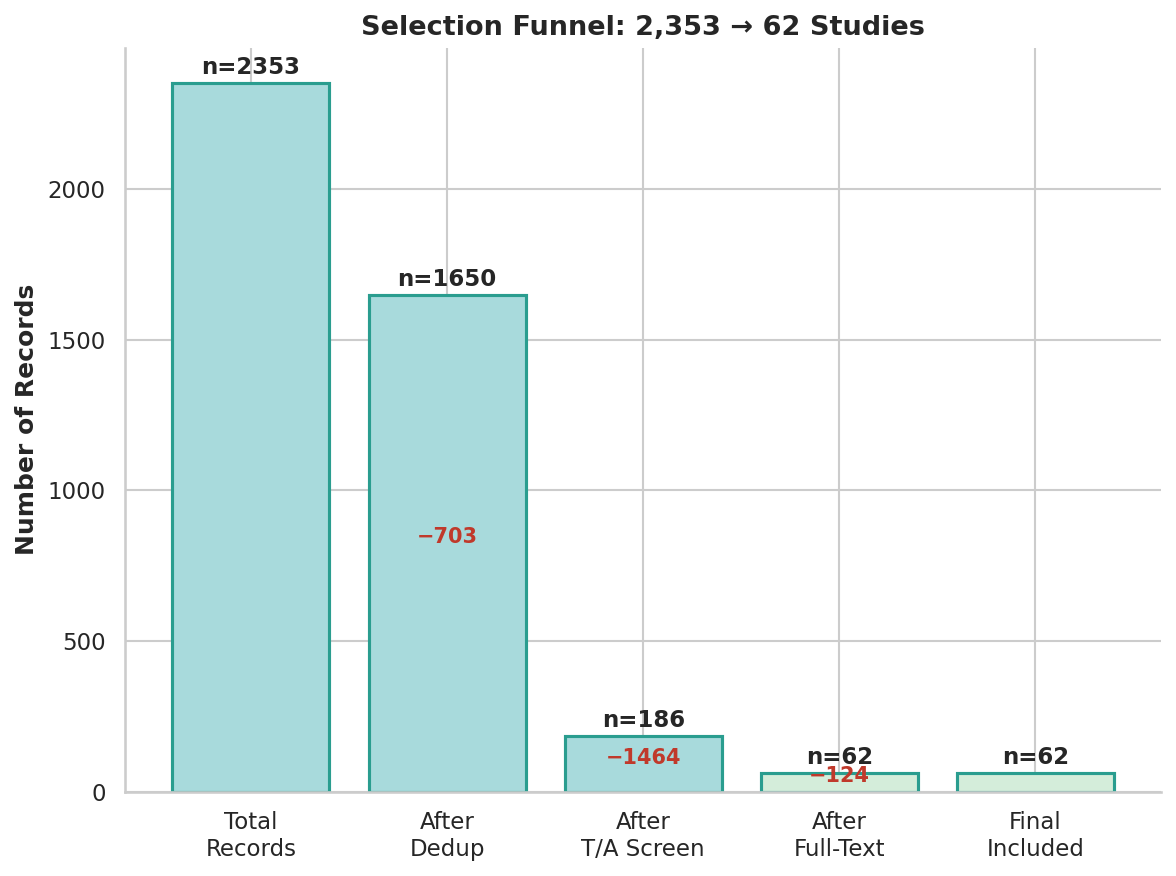


Retention rates:
  Dedup → T/A:     11.3% passed screening
  T/A → Full-text:  33.3% passed full-text
  Overall:           2.63% of initial records included


In [6]:
# Deduplication statistics
dupes_removed = 703
total_before = 2353
unique_after = 1650
dup_rate = dupes_removed / total_before * 100

print(f'Deduplication Summary:')
print(f'  Total records:     {total_before}')
print(f'  Duplicates found:  {dupes_removed} ({dup_rate:.1f}%)')
print(f'  Unique remaining:  {unique_after}')
print(f'  Dedup method:      Automated title matching')

# Visualise the funnel
fig, ax = plt.subplots(figsize=(8, 6))
stages = ['Total\nRecords', 'After\nDedup', 'After\nT/A Screen', 'After\nFull-Text', 'Final\nIncluded']
counts = [2353, 1650, 186, 62, 62]
excluded = [0, 703, 1464, 124, 0]
colors_f = ['#A8DADC', '#A8DADC', '#A8DADC', '#D4EDDA', '#D4EDDA']

bars = ax.bar(stages, counts, color=colors_f, edgecolor='#2A9D8F', linewidth=1.5)
for b, v, e in zip(bars, counts, excluded):
    ax.text(b.get_x()+b.get_width()/2, v+30, f'n={v}', ha='center', fontweight='bold', fontsize=11)
    if e > 0:
        ax.text(b.get_x()+b.get_width()/2, v/2, f'−{e}', ha='center', fontsize=10, color='#C0392B', fontweight='bold')

ax.set_ylabel('Number of Records', fontweight='bold')
ax.set_title('Selection Funnel: 2,353 → 62 Studies', fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.savefig('ext_B_funnel.png', dpi=200, bbox_inches='tight'); plt.show()

# Retention rates
print(f'\nRetention rates:')
print(f'  Dedup → T/A:     {186/1650*100:.1f}% passed screening')
print(f'  T/A → Full-text:  {62/186*100:.1f}% passed full-text')
print(f'  Overall:           {62/2353*100:.2f}% of initial records included')


## Extended Analysis C — Full-Text Exclusion Breakdown


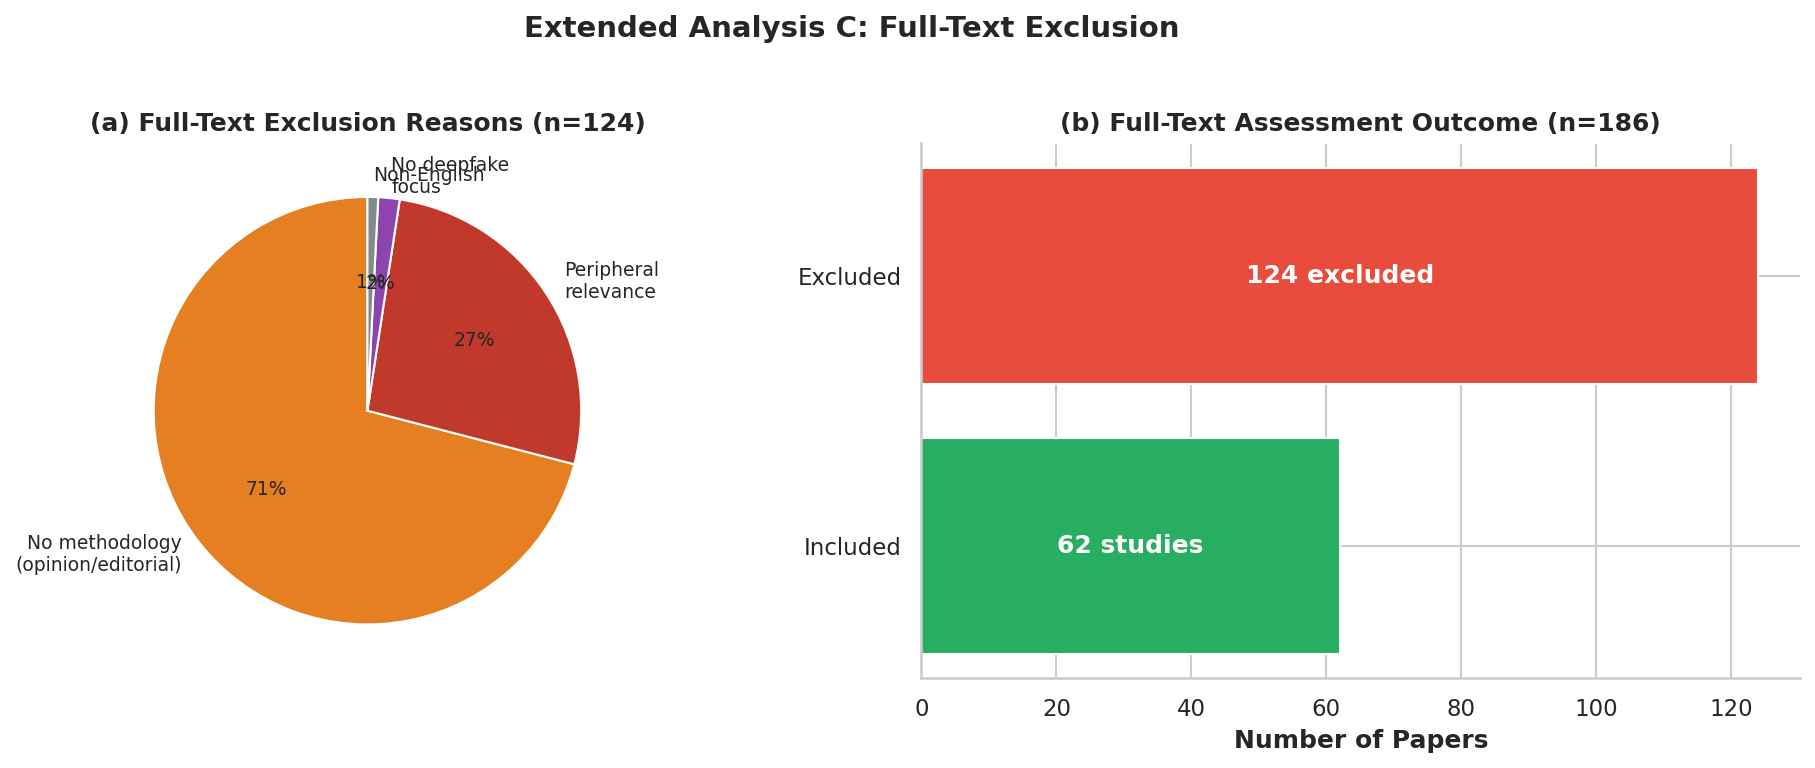

Full-text exclusion breakdown:
  No methodology (opinion/editorial)             88 (71%)
  Peripheral relevance                           33 (27%)
  No deepfake focus                               2 (2%)
  Non-English                                     1 (1%)
  Acceptance rate: 33.3%


In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Pie chart of FT exclusion reasons
reasons = ['No methodology\n(opinion/editorial)', 'Peripheral\nrelevance', 'No deepfake\nfocus', 'Non-English']
counts_ex = [88, 33, 2, 1]
colors_ex = ['#E67E22', '#C0392B', '#8E44AD', '#7F8C8D']
wedges, texts, autotexts = ax1.pie(counts_ex, labels=reasons, autopct='%1.0f%%', colors=colors_ex, startangle=90, textprops={'fontsize':9})
ax1.set_title('(a) Full-Text Exclusion Reasons (n=124)', fontweight='bold')

# Stacked: included vs excluded at FT
ax2.barh(['Included', 'Excluded'], [62, 124], color=['#27AE60', '#E74C3C'], edgecolor='white')
ax2.text(62/2, 0, '62 studies', ha='center', va='center', fontweight='bold', color='white', fontsize=12)
ax2.text(124/2, 1, '124 excluded', ha='center', va='center', fontweight='bold', color='white', fontsize=12)
ax2.set_xlabel('Number of Papers', fontweight='bold')
ax2.set_title('(b) Full-Text Assessment Outcome (n=186)', fontweight='bold')
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

plt.suptitle('Extended Analysis C: Full-Text Exclusion', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('ext_C_fulltext.png', dpi=200, bbox_inches='tight'); plt.show()

print(f'Full-text exclusion breakdown:')
for r, c in zip(['No methodology (opinion/editorial)', 'Peripheral relevance', 'No deepfake focus', 'Non-English'], counts_ex):
    print(f'  {r:45s} {c:3d} ({c/124*100:.0f}%)')
print(f'  Acceptance rate: {62/186*100:.1f}%')


## Extended Analysis D — Cross-Theme Matrix (Primary × Secondary)


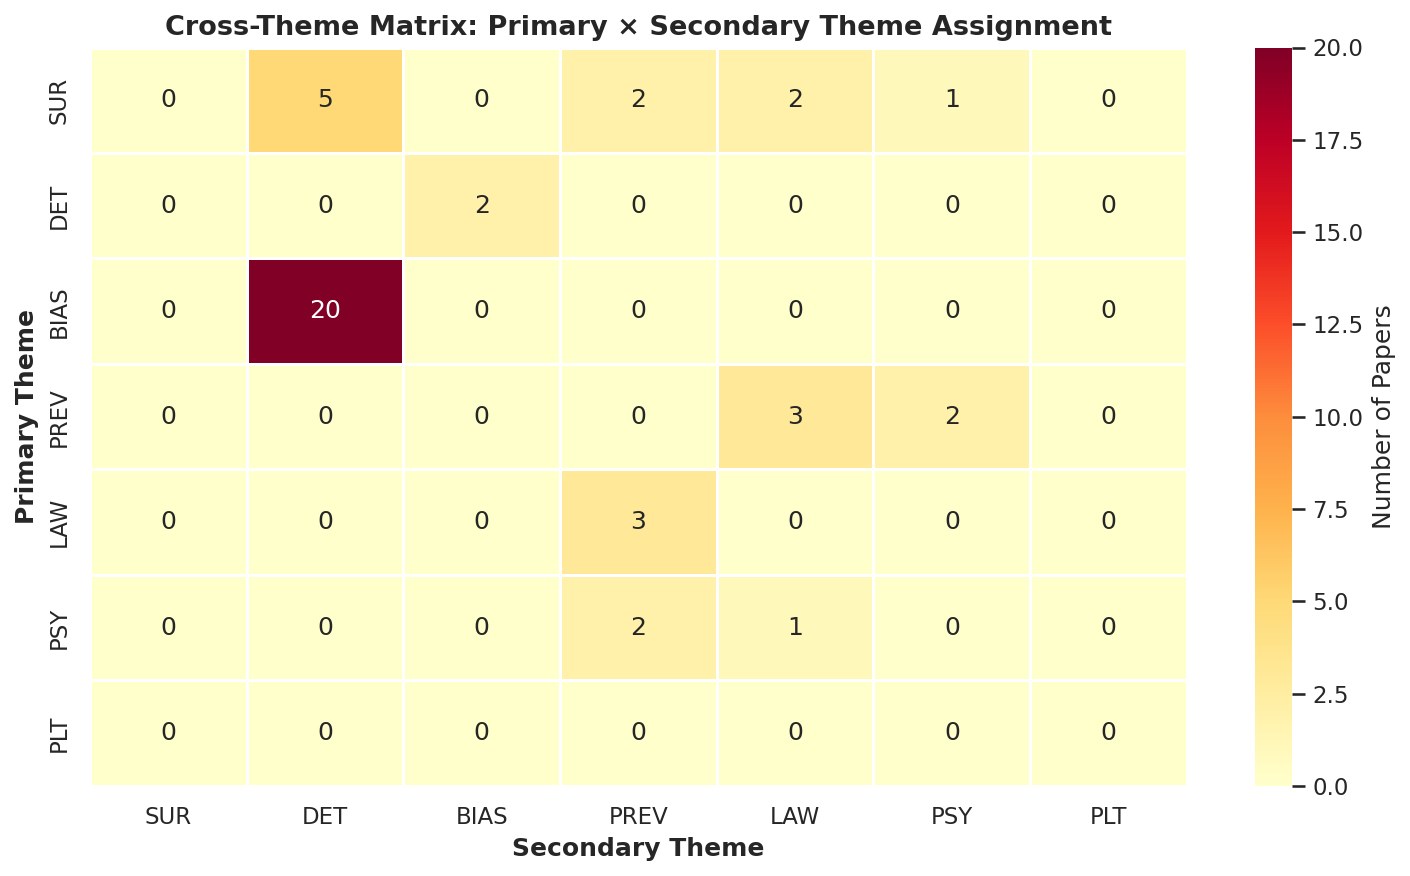

Cross-theme statistics:
  Papers with secondary theme: 43/62 (69%)
  Papers single-theme only:    19/62 (31%)

Strongest cross-theme link: BIAS → DET (20 papers)
  This reflects that all 20 BIAS papers contribute to detection methodology


In [8]:
# Build cross-theme matrix
themes_all = ['SUR','DET','BIAS','PREV','LAW','PSY','PLT','—']
matrix = pd.DataFrame(0, index=theme_order, columns=themes_all)
for _, row in df.iterrows():
    matrix.loc[row['Theme'], row['Secondary']] += 1

# Heatmap (exclude '—' column for visual clarity)
fig, ax = plt.subplots(figsize=(10, 6))
matrix_viz = matrix[theme_order].copy()
sns.heatmap(matrix_viz, annot=True, fmt='d', cmap='YlOrRd', ax=ax, linewidths=0.5,
            cbar_kws={'label': 'Number of Papers'})
ax.set_xlabel('Secondary Theme', fontweight='bold'); ax.set_ylabel('Primary Theme', fontweight='bold')
ax.set_title('Cross-Theme Matrix: Primary × Secondary Theme Assignment', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('ext_D_crosstheme.png', dpi=200, bbox_inches='tight'); plt.show()

# Stats
has_secondary = (df.Secondary != '—').sum()
print(f'Cross-theme statistics:')
print(f'  Papers with secondary theme: {has_secondary}/{len(df)} ({has_secondary/len(df)*100:.0f}%)')
print(f'  Papers single-theme only:    {len(df)-has_secondary}/{len(df)} ({(len(df)-has_secondary)/len(df)*100:.0f}%)')
print(f'\nStrongest cross-theme link: BIAS → DET ({matrix.loc["BIAS","DET"]} papers)')
print(f'  This reflects that all 20 BIAS papers contribute to detection methodology')


## Extended Analysis E — Publication Venue Type


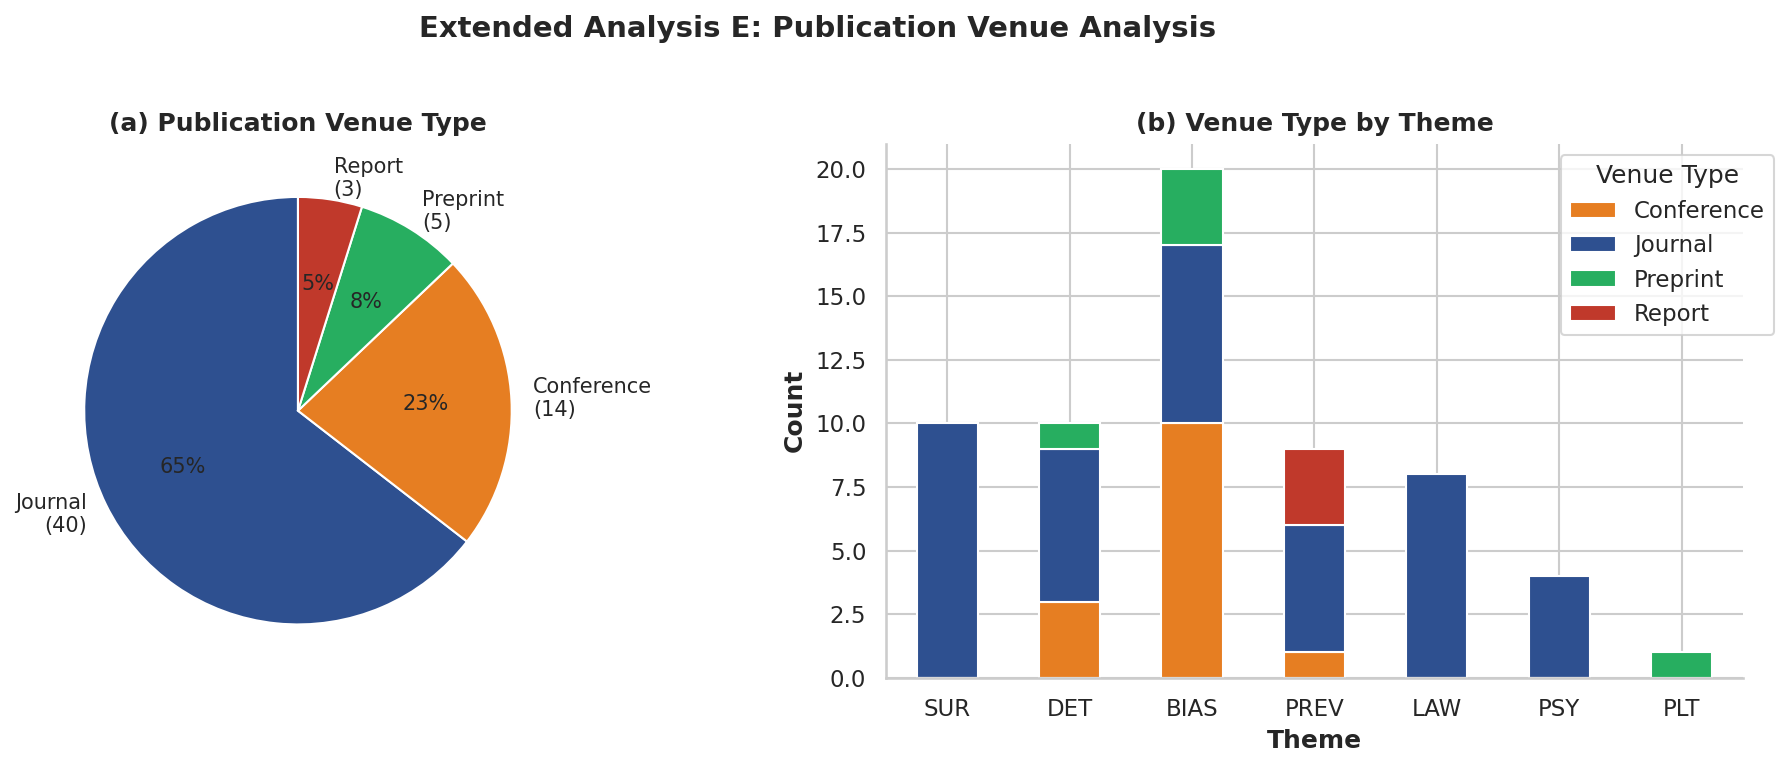

Venue type breakdown:
  Journal      40 (65%)
  Conference   14 (23%)
  Preprint      5 (8%)
  Report        3 (5%)

BIAS papers in conferences: 10 / 20


In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Venue type breakdown
vt = df.VenueType.value_counts()
ax1.pie(vt.values, labels=[f'{k}\n({v})' for k,v in vt.items()], autopct='%1.0f%%',
        colors=['#2E5090','#E67E22','#27AE60','#C0392B'], startangle=90, textprops={'fontsize':10})
ax1.set_title('(a) Publication Venue Type', fontweight='bold')

# Venue type by theme
vt_theme = df.groupby(['Theme','VenueType']).size().unstack(fill_value=0)
vt_theme = vt_theme.reindex(theme_order)
vt_theme.plot(kind='bar', stacked=True, ax=ax2, color=['#E67E22','#2E5090','#27AE60','#C0392B'], edgecolor='white')
ax2.set_xlabel('Theme', fontweight='bold'); ax2.set_ylabel('Count', fontweight='bold')
ax2.set_title('(b) Venue Type by Theme', fontweight='bold')
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)
ax2.legend(title='Venue Type', bbox_to_anchor=(1.05, 1)); ax2.set_xticklabels(theme_order, rotation=0)

plt.suptitle('Extended Analysis E: Publication Venue Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('ext_E_venues.png', dpi=200, bbox_inches='tight'); plt.show()

print('Venue type breakdown:')
for vtype, count in vt.items(): print(f'  {vtype:12s} {count:2d} ({count/len(df)*100:.0f}%)')
print(f'\nBIAS papers in conferences: {len(df[(df.Theme=="BIAS") & (df.VenueType=="Conference")])} / {(df.Theme=="BIAS").sum()}')


## Extended Analysis F — Year × Theme Heatmap


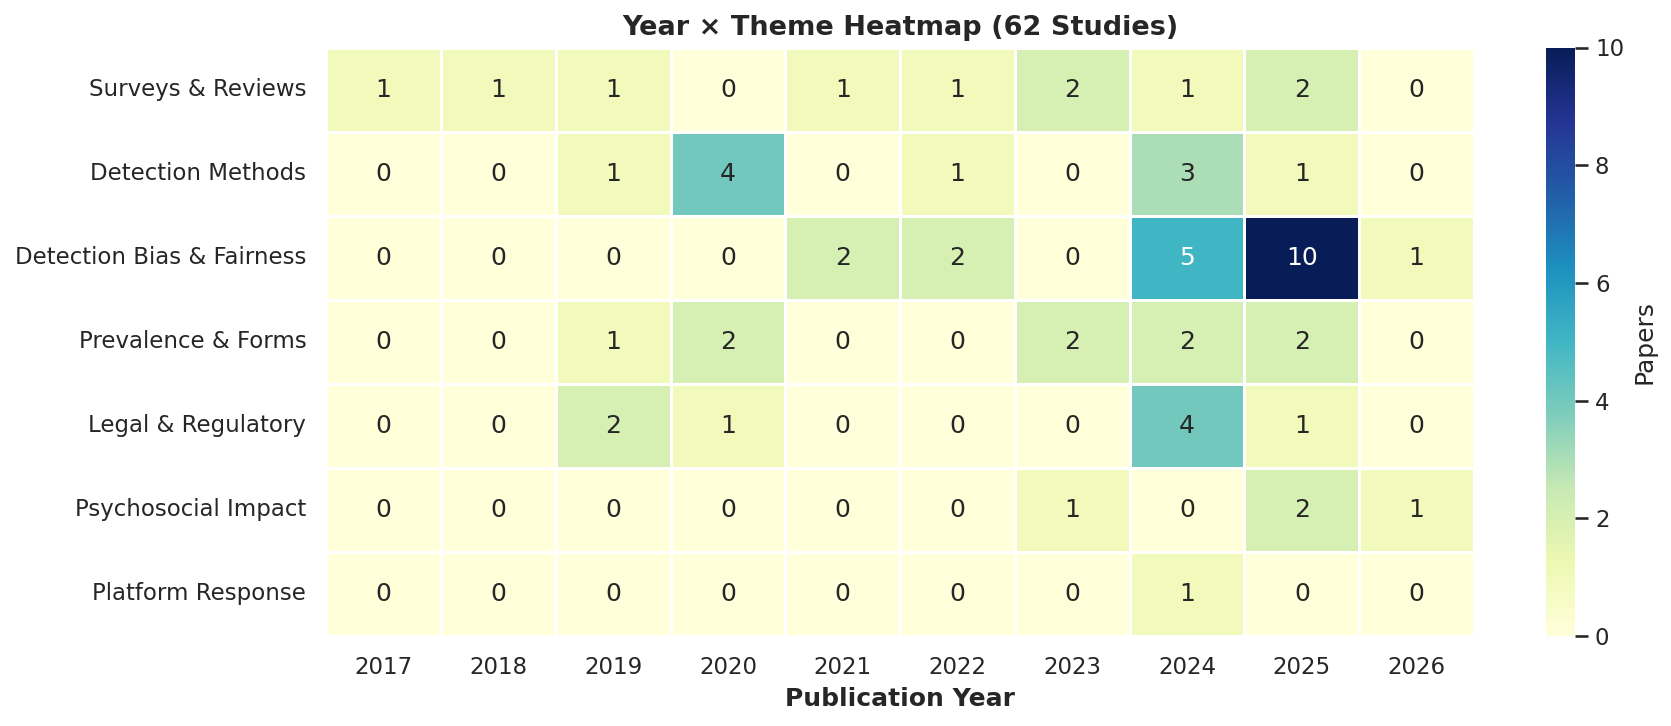

Key observations:
  BIAS papers concentrated in 2024-2026: 16 of 20
  DET papers span 2019-2025 (more established field)
  LAW papers spike in 2024-2025 (legislative response to crisis)
  PSY papers all from 2023-2026 (emerging research area)


In [11]:
fig, ax = plt.subplots(figsize=(12, 5))
yt = df.groupby(['Year','Theme']).size().unstack(fill_value=0)
yt = yt.reindex(columns=theme_order, fill_value=0)
yt.index = yt.index.astype(int)

sns.heatmap(yt.T, annot=True, fmt='d', cmap='YlGnBu', ax=ax, linewidths=0.5,
            cbar_kws={'label': 'Papers'}, yticklabels=[theme_full.get(t,t) for t in theme_order])
ax.set_xlabel('Publication Year', fontweight='bold'); ax.set_ylabel('')
ax.set_title('Year × Theme Heatmap (62 Studies)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('ext_F_heatmap.png', dpi=200, bbox_inches='tight'); plt.show()

print('Key observations:')
print(f'  BIAS papers concentrated in 2024-2026: {len(df[(df.Theme=="BIAS") & (df.Year>=2024)])} of {(df.Theme=="BIAS").sum()}')
print(f'  DET papers span 2019-2025 (more established field)')
print(f'  LAW papers spike in 2024-2025 (legislative response to crisis)')
print(f'  PSY papers all from 2023-2026 (emerging research area)')


## Extended Analysis G — Detection Bias & Fairness Deep Dive (20 BIAS Papers)


BIAS theme: 20 papers (32% of corpus)
Year range: 2021–2026



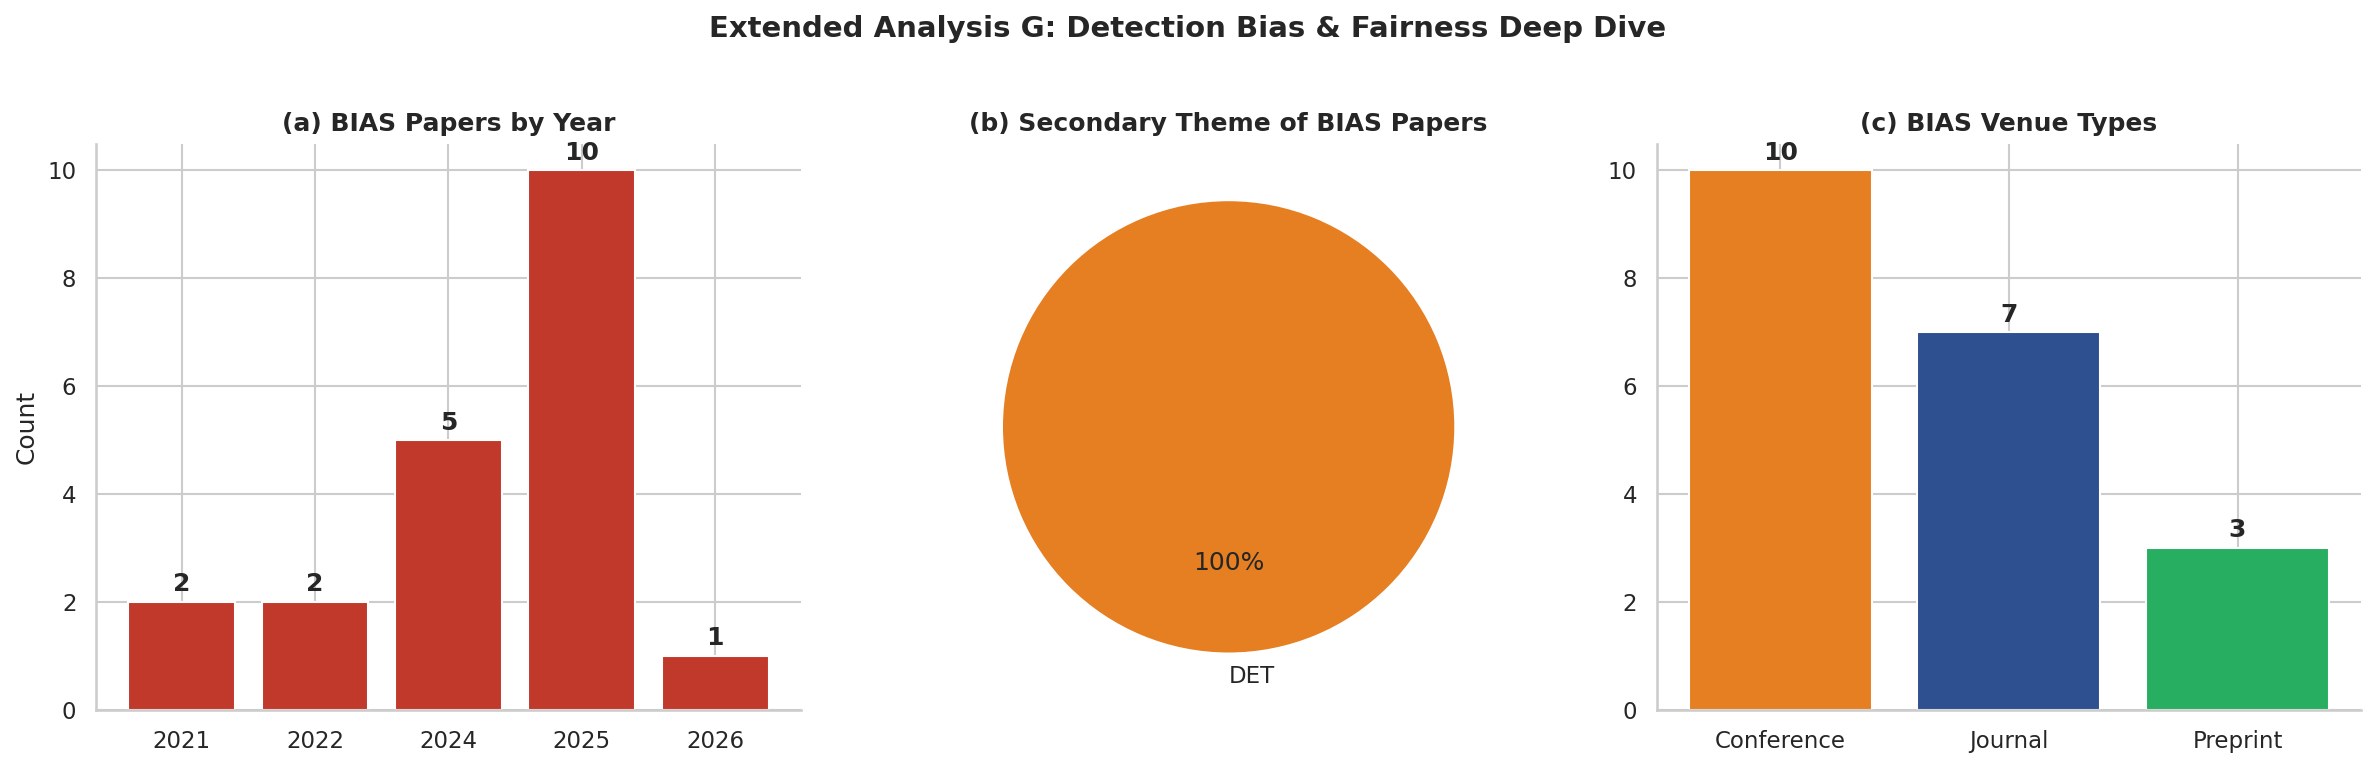

BIAS paper listing:
  S28 Trinh & Liu               (2021) — IJCAI 2021
  S29 Nadimpalli & Rattani      (2022) — ICPR 2022
  S30 Xu et al.                 (2024) — IEEE Trans. Tech & Society
  S31 Hazirbas et al.           (2021) — CVPR 2021 Workshops
  S32 Ju et al.                 (2024) — WACV 2024
  S33 Lin et al.                (2024) — CVPR 2024
  S34 Ezeakunne et al.          (2025) — ICAART 2025
  S35 Peng et al.               (2025) — Neural Networks
  S36 Yoshi et al.              (2025) — arXiv
  S37 Cheng et al.              (2025) — arXiv
  S48 Panda et al.              (2026) — ACM Computing Surveys
  S49 Khalid et al.             (2024) — IEEE Access
  S50 Li et al.                 (2025) — IEEE TIFS
  S51 Hou et al.                (2025) — arXiv / AAAI 2025
  S52 Pu et al.                 (2022) — AEQUITAS Workshop
  S53 Deng et al.               (2024) — arXiv / Multimedia
  S54 Cai et al.                (2025) — arXiv / CVPR 2025
  S55 Hou et al.                (2025)

In [12]:
bias_papers = df[df.Theme == 'BIAS'].copy()
print(f'BIAS theme: {len(bias_papers)} papers ({len(bias_papers)/len(df)*100:.0f}% of corpus)')
print(f'Year range: {bias_papers.Year.min():.0f}–{bias_papers.Year.max():.0f}')
print()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Timeline of BIAS papers
ax = axes[0]
byear = bias_papers.Year.value_counts().sort_index()
ax.bar(byear.index.astype(int).astype(str), byear.values, color='#C0392B', edgecolor='white')
for i, (y, v) in enumerate(byear.items()): ax.text(i, v+0.2, str(v), ha='center', fontweight='bold')
ax.set_title('(a) BIAS Papers by Year', fontweight='bold')
ax.set_ylabel('Count'); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# All BIAS papers have DET as secondary
ax2 = axes[1]
sec = bias_papers.Secondary.value_counts()
ax2.pie(sec.values, labels=sec.index, autopct='%1.0f%%', colors=['#E67E22','#27AE60'], startangle=90)
ax2.set_title('(b) Secondary Theme of BIAS Papers', fontweight='bold')

# Venue type for BIAS
ax3 = axes[2]
bvt = bias_papers.VenueType.value_counts()
ax3.bar(bvt.index, bvt.values, color=['#E67E22','#2E5090','#27AE60'], edgecolor='white')
for i, v in enumerate(bvt.values): ax3.text(i, v+0.2, str(v), ha='center', fontweight='bold')
ax3.set_title('(c) BIAS Venue Types', fontweight='bold')
ax3.spines['top'].set_visible(False); ax3.spines['right'].set_visible(False)

plt.suptitle('Extended Analysis G: Detection Bias & Fairness Deep Dive', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('ext_G_bias_deep.png', dpi=200, bbox_inches='tight'); plt.show()

print('BIAS paper listing:')
for _, r in bias_papers.iterrows():
    print(f'  {r.ID} {r.Authors:25s} ({r.Year:.0f}) — {r.Venue}')


## Extended Analysis H — Cumulative Growth & Research Gaps


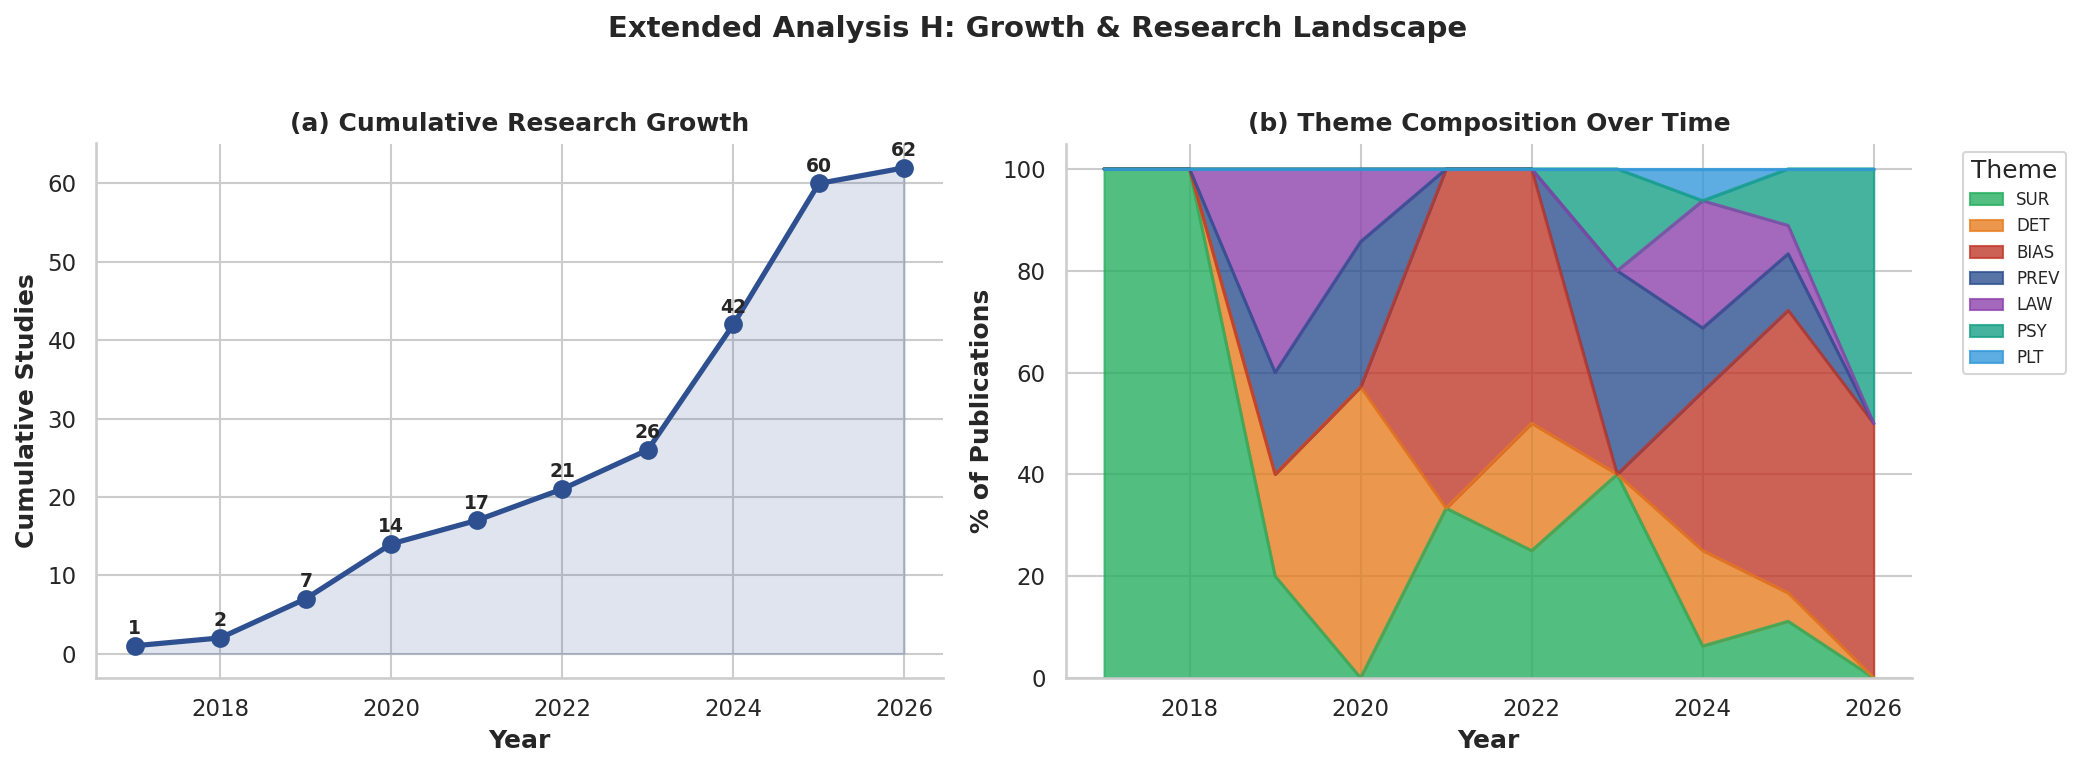

Growth statistics:
  2017-2021 (foundational): 17 papers
  2022-2023 (growth):       9 papers
  2024-2026 (peak):         36 papers (58% of total)
  Doubling period: corpus doubled from ~20 to ~40 between 2023 and 2025


In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Cumulative growth
years = sorted(df.Year.unique())
cumulative = [len(df[df.Year <= y]) for y in years]
ax1.plot([int(y) for y in years], cumulative, 'o-', color='#2E5090', linewidth=2.5, markersize=8)
ax1.fill_between([int(y) for y in years], cumulative, alpha=0.15, color='#2E5090')
for y, c in zip(years, cumulative): ax1.text(int(y), c+1.5, str(c), ha='center', fontsize=9, fontweight='bold')
ax1.set_xlabel('Year', fontweight='bold'); ax1.set_ylabel('Cumulative Studies', fontweight='bold')
ax1.set_title('(a) Cumulative Research Growth', fontweight='bold')
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)

# Research gaps: theme coverage as % of total by year
ax2_data = df.groupby([df.Year.astype(int), 'Theme']).size().unstack(fill_value=0)
ax2_data = ax2_data.reindex(columns=theme_order, fill_value=0)
ax2_data_pct = ax2_data.div(ax2_data.sum(axis=1), axis=0) * 100
ax2_data_pct.plot(kind='area', stacked=True, ax=ax2, color=colors7, alpha=0.8)
ax2.set_xlabel('Year', fontweight='bold'); ax2.set_ylabel('% of Publications', fontweight='bold')
ax2.set_title('(b) Theme Composition Over Time', fontweight='bold')
ax2.legend(title='Theme', bbox_to_anchor=(1.05, 1), fontsize=8)
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

plt.suptitle('Extended Analysis H: Growth & Research Landscape', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('ext_H_growth.png', dpi=200, bbox_inches='tight'); plt.show()

print('Growth statistics:')
print(f'  2017-2021 (foundational): {len(df[df.Year<=2021])} papers')
print(f'  2022-2023 (growth):       {len(df[(df.Year>=2022)&(df.Year<=2023)])} papers')
print(f'  2024-2026 (peak):         {len(df[df.Year>=2024])} papers ({len(df[df.Year>=2024])/len(df)*100:.0f}% of total)')
print(f'  Doubling period: corpus doubled from ~20 to ~40 between 2023 and 2025')


## Summary Dashboard


In [14]:
print('=' * 60)
print('SLR EXTENDED ANALYSIS SUMMARY — 62 VERIFIED STUDIES')
print('=' * 60)
print(f'Total studies:     {len(df)}')
print(f'Year range:        {df.Year.min():.0f}–{df.Year.max():.0f}')
print(f'Peak year:         {df.Year.value_counts().idxmax():.0f} ({df.Year.value_counts().max()} studies)')
print(f'Databases:         6 (Scopus, IEEE, ACM, WoS, PubMed, Google Scholar)')
print(f'Total retrieved:   2,353 records')
print(f'Acceptance rate:   {62/2353*100:.2f}%')
print()
print('Theme breakdown (primary):')
for t in theme_order:
    n = (df.Theme==t).sum()
    print(f'  {t:5s} {theme_full[t]:30s} {n:2d} ({n/len(df)*100:4.1f}%)')
print()
print('Venue types:')
for vt, n in df.VenueType.value_counts().items():
    print(f'  {vt:12s} {n:2d} ({n/len(df)*100:4.1f}%)')
print()
print('Cross-theme insights:')
print(f'  Papers with secondary theme: {(df.Secondary!="—").sum()} ({(df.Secondary!="—").sum()/len(df)*100:.0f}%)')
print(f'  Strongest link: BIAS↔DET (all 20 BIAS papers list DET as secondary)')
print()
print('Key growth metrics:')
print(f'  Pre-2024 papers:  {len(df[df.Year<2024])} ({len(df[df.Year<2024])/len(df)*100:.0f}%)')
print(f'  2024+ papers:     {len(df[df.Year>=2024])} ({len(df[df.Year>=2024])/len(df)*100:.0f}%)')
print(f'  BIAS field growth: {len(df[(df.Theme=="BIAS")&(df.Year>=2024)])} of 20 BIAS papers from 2024+')
print()
print('Figures generated: 4 main + 8 extended analyses')
print('=' * 60)


SLR EXTENDED ANALYSIS SUMMARY — 62 VERIFIED STUDIES
Total studies:     62
Year range:        2017–2026
Peak year:         2025 (18 studies)
Databases:         6 (Scopus, IEEE, ACM, WoS, PubMed, Google Scholar)
Total retrieved:   2,353 records
Acceptance rate:   2.63%

Theme breakdown (primary):
  SUR   Surveys & Reviews              10 (16.1%)
  DET   Detection Methods              10 (16.1%)
  BIAS  Detection Bias & Fairness      20 (32.3%)
  PREV  Prevalence & Forms              9 (14.5%)
  LAW   Legal & Regulatory              8 (12.9%)
  PSY   Psychosocial Impact             4 ( 6.5%)
  PLT   Platform Response               1 ( 1.6%)

Venue types:
  Journal      40 (64.5%)
  Conference   14 (22.6%)
  Preprint      5 ( 8.1%)
  Report        3 ( 4.8%)

Cross-theme insights:
  Papers with secondary theme: 43 (69%)
  Strongest link: BIAS↔DET (all 20 BIAS papers list DET as secondary)

Key growth metrics:
  Pre-2024 papers:  26 (42%)
  2024+ papers:     36 (58%)
  BIAS field growth: 16 

---
## Citation
```
[Author] (2026). Deepfakes as Gendered Weapons: A Systematic Literature Review
Bridging Face-Swap Detection Bias, Platform Failures, and Gender-Based Violence.
```
